In [1]:
%matplotlib widget
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import plotnine as p9

sns.set_style("whitegrid")
Path.cwd()
data_dir = (Path.cwd().parent / ".data/extra-L02").resolve()
assert data_dir.exists()

In [2]:
list(f"{pth.stem}{pth.suffix}" for pth in data_dir.glob("*"))

['tourism.xlsx', 'tute1.csv']

In [3]:
df = (
    pd.read_csv(data_dir / "tute1.csv", sep=",")
    .assign(Quarter=lambda df: pd.to_datetime(df["Quarter"]))
    .set_index("Quarter")
)
df

,Sales,AdBudget,GDP
Quarter,,,
1981-03-01,1020.2,659.2,251.8
1981-06-01,889.2,589.0,290.9
1981-09-01,795.0,512.5,290.8
1981-12-01,1003.9,614.1,292.4
1982-03-01,1057.7,647.2,279.1
...,...,...,...
2004-12-01,1018.7,634.9,284.0
2005-03-01,1112.5,663.1,270.9
2005-06-01,997.4,583.3,294.7


Text(0.5, 1.0, 'Sales per Quarter')

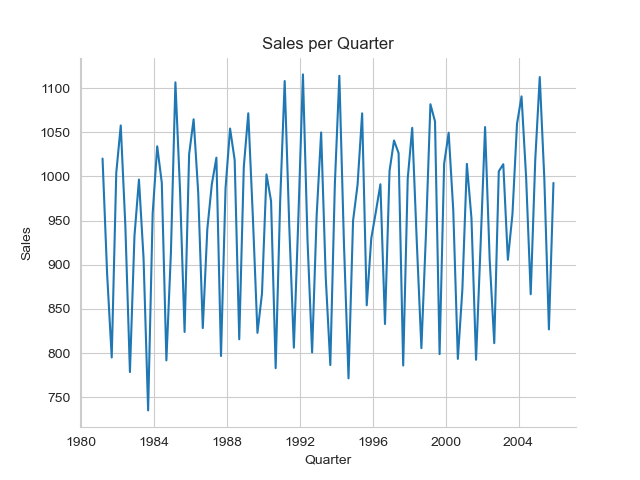

In [4]:
sns.lineplot(
    data=df,
    x=df.index,
    y="Sales",

)
sns.despine()
plt.title("Sales per Quarter")

In [ ]:
sns.scatterplot(
    data=df,
    x="AdBudget",
    y="Sales",
)
sns.despine()

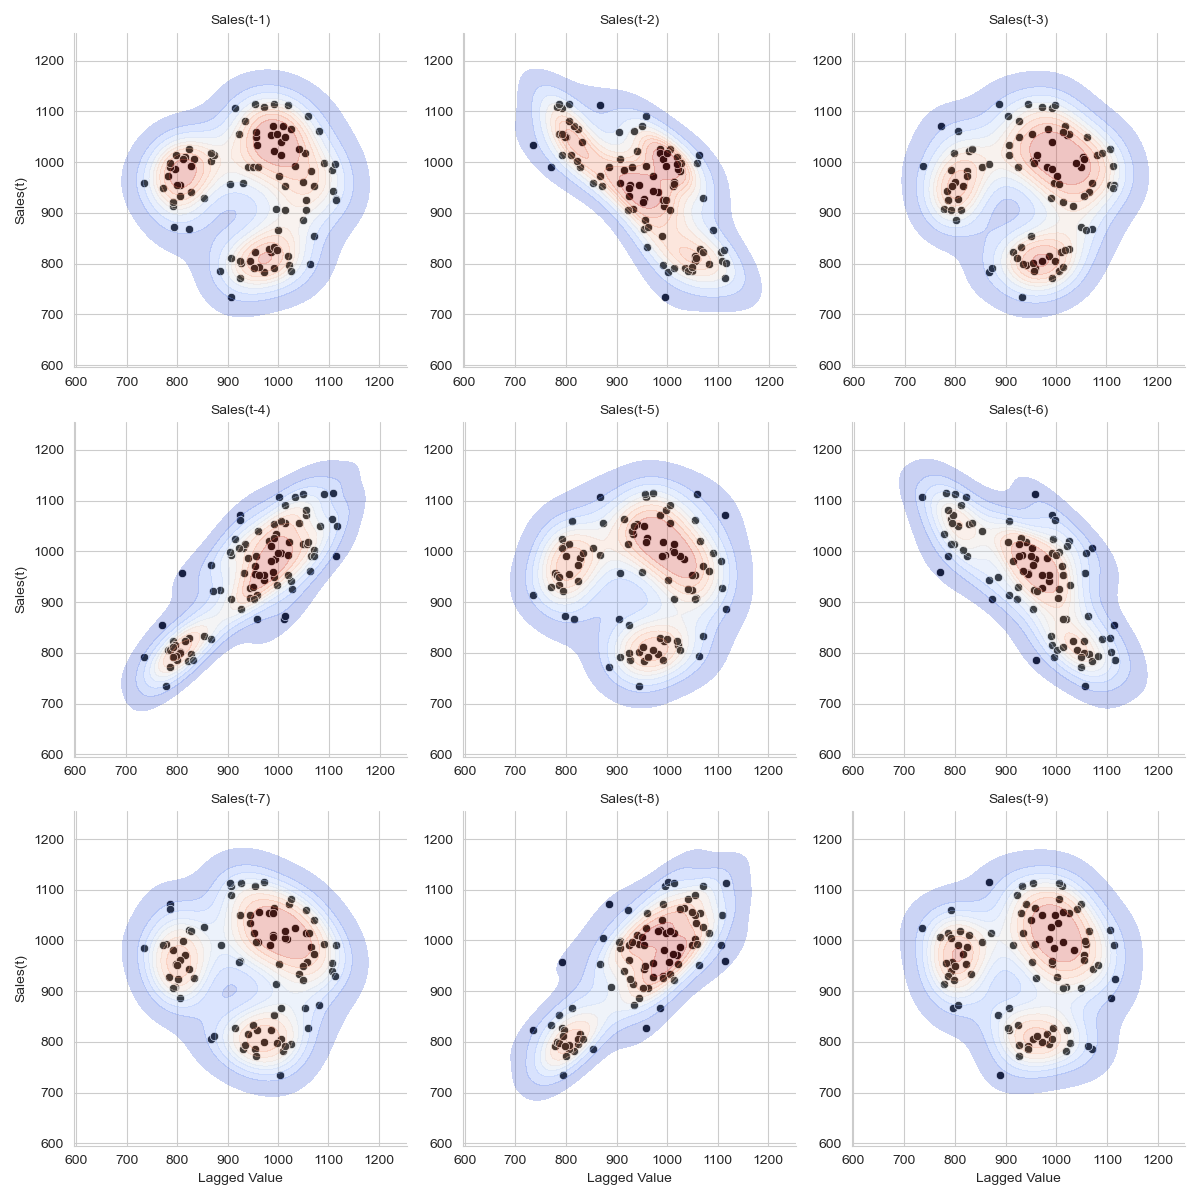

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Iterable

def lag_plot(
    df: pd.DataFrame,
    value_column: str,
    lags: Iterable[int],
    col_wrap: int = 4,
) -> sns.FacetGrid:
    """
    Creates lag plots for a time series using the specified lags, with a superimposed KDE.

    Args:
        df : pd.DataFrame
            The DataFrame containing the time series data, with the time column as the index.
        value_column : str
            The column name containing the values to be plotted.
        lags : Iterable[int]
            Iterable of lags to create the lag plots for (e.g., [1, 2, 3]).
        col_wrap : int, optional
            The number of columns to wrap the plots into. Default is 4.
        palette : str, optional
            The color palette to use for the KDE. Default is 'coolwarm'.

    Returns:
        sns.FacetGrid
            A Seaborn FacetGrid object containing the lag plots.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("The DataFrame must have a DatetimeIndex as its index.")

    # Compute lags values
    lagged_data = dict(map((lambda x: (f"{value_column}(t-{x})", df[value_column].shift(x))), lags))
    lagged_data[value_column] = df[value_column]
    lag_df = pd.DataFrame(lagged_data)
    lag_df = lag_df.dropna().melt(id_vars=value_column, var_name='Lag', value_name='Lagged Value')

    # Create FacetGrid
    g = sns.FacetGrid(lag_df, col="Lag", col_wrap=col_wrap, height=4, sharex=False, sharey=False)
    g.map_dataframe(sns.scatterplot, x='Lagged Value', y=value_column, color="black")
    g.map_dataframe(sns.kdeplot, x='Lagged Value', y=value_column, fill=True, levels=5, alpha=0.5, cmap='coolwarm')

    # Adjust color intensity and reverse it to match high density = red
    for ax in g.axes.flat:
        ax.collections[1].set_alpha(0.3)

    g.set_axis_labels("Lagged Value", f"{value_column}(t)")
    g.set_titles(col_template="{col_name}")

    plt.tight_layout()
    return g

# Example usage
fig = lag_plot(df, "Sales", lags=range(1, 10), col_wrap=3)
plt.show()

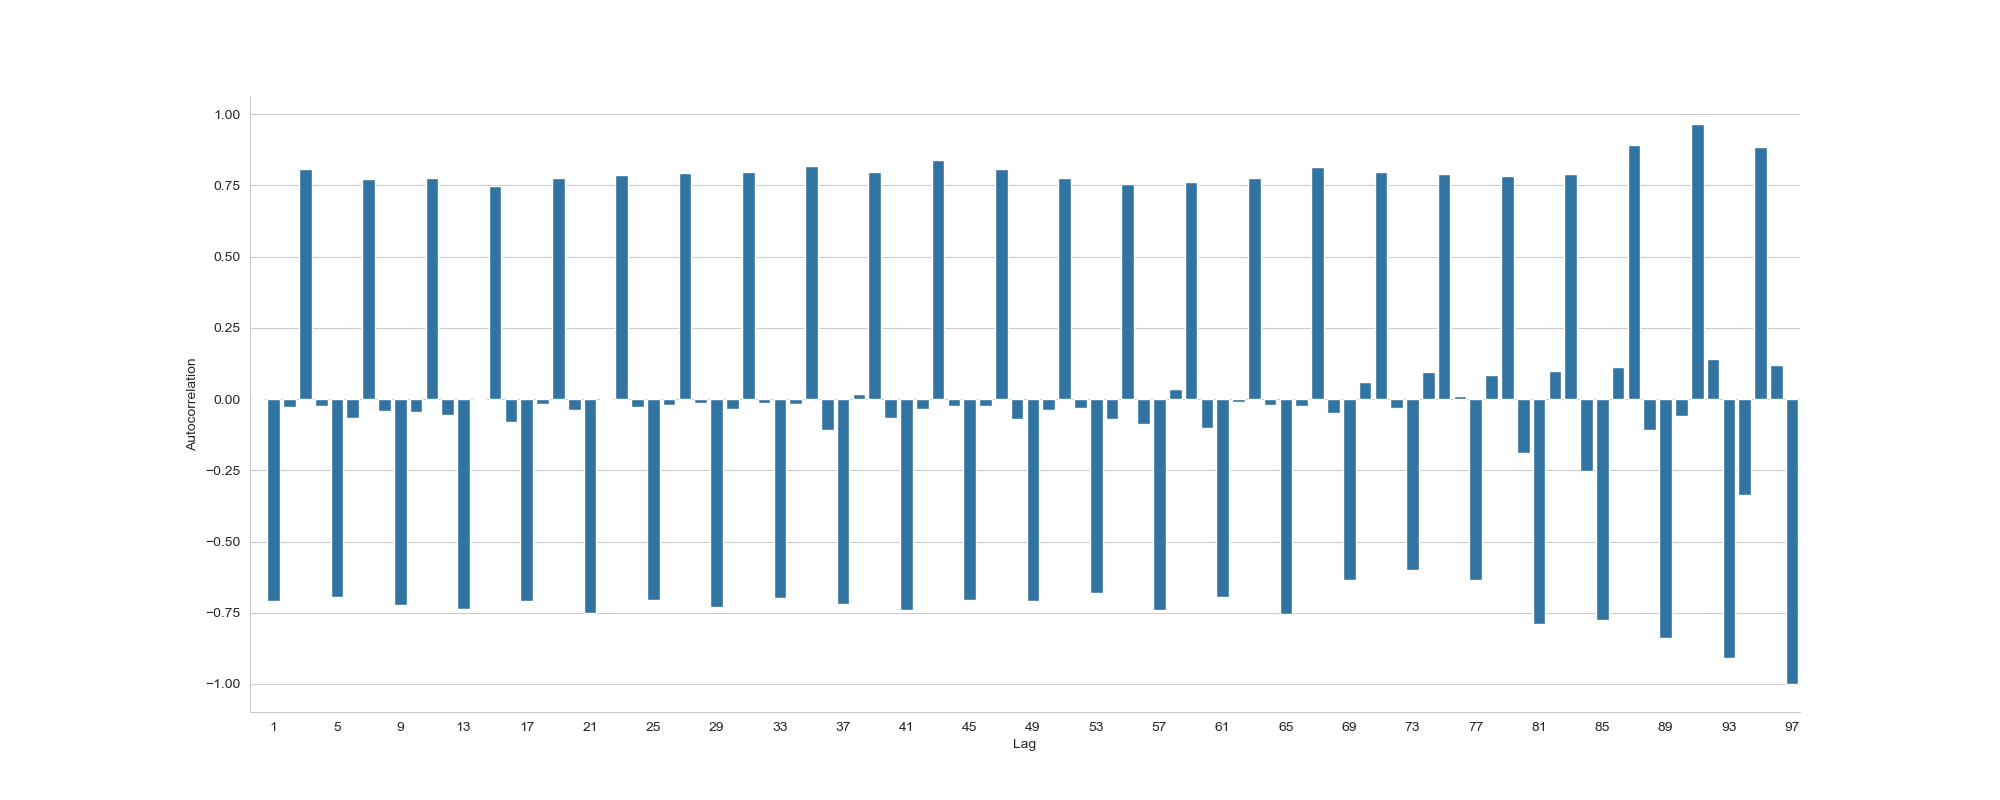

In [7]:
K_MAX = 99
autocorr_values = list(
    map(
        lambda k: df["Sales"].autocorr(lag=k), range(1, K_MAX)
    )
)

k_values = range(1, K_MAX, 4)
autocorr_values_every_4th = [autocorr_values[k-1] for k in k_values]

plt.figure(figsize=(20, 8))
sns.barplot(
    x=range(1, K_MAX),
    y=autocorr_values,
)
sns.despine()
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.xticks(ticks=k_values, labels=k_values)
plt.show()